# LLM Cost Dashboard

This notebook shows cost tracking and cache savings metrics for Article 6.

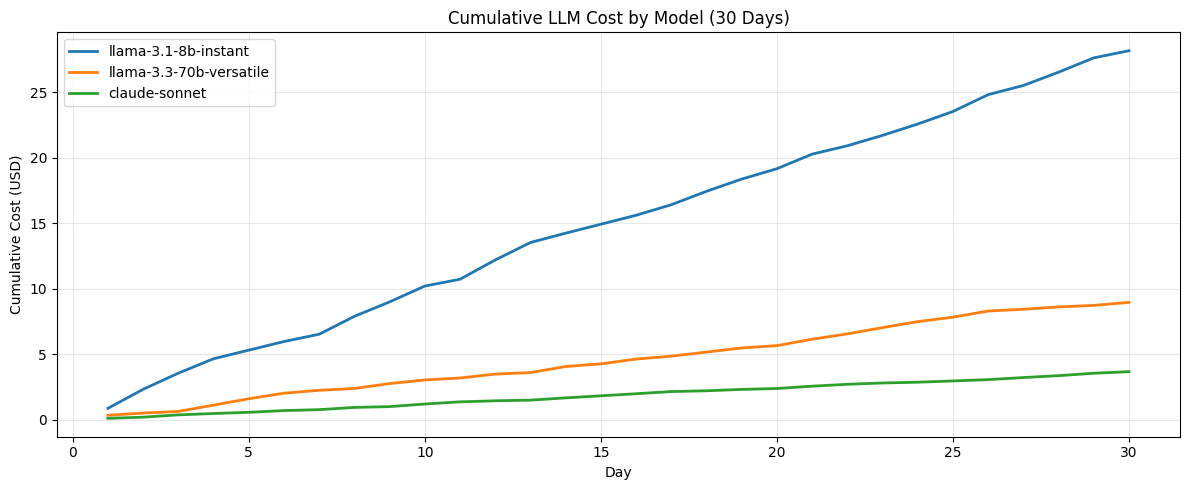

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root regardless of notebook kernel CWD
# nbconvert runs the kernel from the notebook's directory, so we
# climb one level up to reach the project root.
notebook_dir = Path.cwd()
project_root = notebook_dir if (notebook_dir / "pyproject.toml").exists() else notebook_dir.parent
charts_dir = project_root / "results" / "charts" / "article_06"
charts_dir.mkdir(parents=True, exist_ok=True)

# Simulate 30 days of cost data per model
np.random.seed(42)
days = np.arange(1, 31)
models = {
    "groq/llama-3.1-8b-instant": np.random.uniform(0.5, 1.5, 30),
    "groq/llama-3.3-70b-versatile": np.random.uniform(0.1, 0.5, 30),
    "anthropic/claude-sonnet": np.random.uniform(0.05, 0.2, 30),
}

fig, ax = plt.subplots(figsize=(12, 5))
for model, costs in models.items():
    ax.plot(days, np.cumsum(costs), label=model.split("/")[-1], linewidth=2)
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative Cost (USD)")
ax.set_title("Cumulative LLM Cost by Model (30 Days)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(charts_dir / "01_cumulative_cost.png", dpi=150)
plt.show()

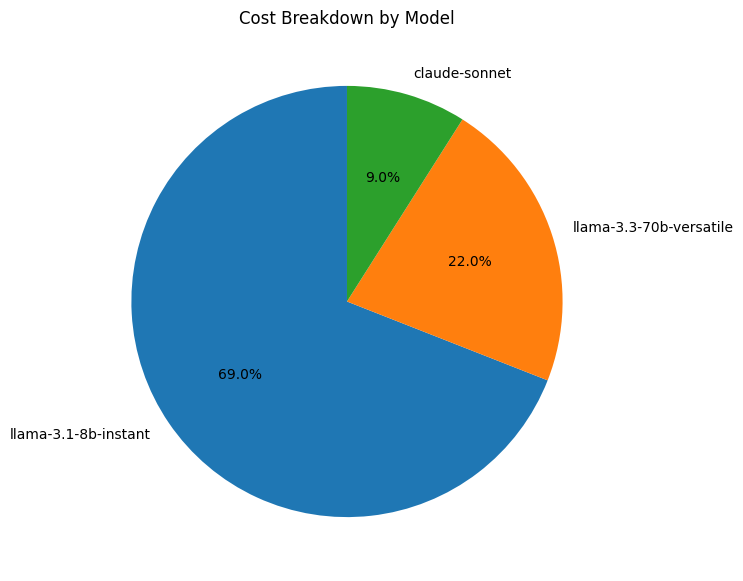

In [2]:
total_by_model = {k: v.sum() for k, v in models.items()}
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    total_by_model.values(),
    labels=[k.split("/")[-1] for k in total_by_model],
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title("Cost Breakdown by Model")
plt.savefig(charts_dir / "02_cost_breakdown.png", dpi=150)
plt.show()

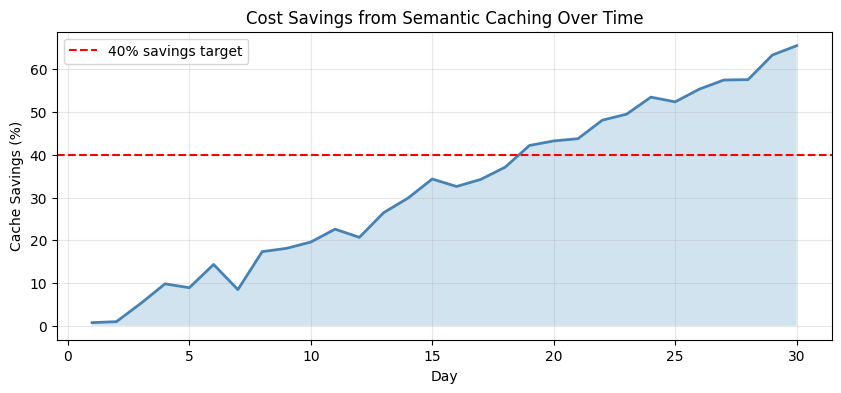

In [3]:
cache_hit_rates = np.linspace(0, 0.65, 30) + np.random.normal(0, 0.02, 30).clip(-0.05, 0.05)
savings_pct = cache_hit_rates * 100
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(days, savings_pct, color="steelblue", linewidth=2)
ax.axhline(y=40, color="red", linestyle="--", label="40% savings target")
ax.fill_between(days, savings_pct, alpha=0.2)
ax.set_xlabel("Day")
ax.set_ylabel("Cache Savings (%)")
ax.set_title("Cost Savings from Semantic Caching Over Time")
ax.legend()
ax.grid(alpha=0.3)
plt.savefig(charts_dir / "03_cache_savings.png", dpi=150)
plt.show()